This script fetches and processes protein data from the Uniprot API to create
positive and negative datasets for signal peptide analysis.

The script performs the following steps:
1. Defines a session with retry logic for robust API calls.
2. Implements a pagination mechanism to handle large search results.
3. Fetches a positive dataset of proteins with experimental signal peptides.
4. Extracts specific fields (including sequence) and filters the data based on defined criteria.
5. Fetches a negative dataset of proteins that are secreted but lack a
   signal peptide.
6. Extracts relevant fields (including sequence) from the negative dataset, including
   information about N-terminal transmembrane helices.
7. Saves both datasets to separate TSV and FASTA files.
8. Reads the generated TSV files into pandas DataFrames for a final summary.


# Part A: Data Gathering

In [ ]:
import requests
import re
import json
import pandas as pd
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# We use the Session object to allow retries in case of temporary service unavailability.
# This configures it to try up to 5 times if it encounters specific server errors.
retries = Retry(total=5, backoff_factor=0.25, status_forcelist=[500, 502, 503, 504])
session = requests.Session()
session.mount("https://", HTTPAdapter(max_retries=retries))

In [ ]:
def get_next_link(headers):
    """
    Extracts the URL for the next page of results from the API response headers.
    """
    if "Link" in headers:
        # The regular expression is used to extract the next link for pagination
        re_next_link = re.compile(r'<(.+)>; rel="next"')
        match = re_next_link.match(headers["Link"])
        if match:
            return match.group(1)
    return None

def get_batch(batch_url):
    """
    Retrieves data one batch (page) at a time from a given URL.
    """
    while batch_url:
        # Run the API call
        response = session.get(batch_url)
        # Will raise an error if an unsuccessful status code is obtained
        response.raise_for_status()
        # Get the total number of entries in the search
        total = response.headers.get("x-total-results", "0")
        # Yield the response and the total number of entries
        yield response, total
        # Get the link to the API call for the next data batch
        batch_url = get_next_link(response.headers)

def get_eukaryotic_kingdom(lineage):
    """
    Categorizes an organism into Metazoa, Fungi, Plants, or Other based on its lineage.
    """
    if "Metazoa" in lineage:
        return "Metazoa"
    if "Fungi" in lineage:
        return "Fungi"
    if "Viridiplantae" in lineage:  # Viridiplantae is the taxonomic group for green plants
        return "Plants"
    return "Other"


def extract_fields_positive(entry):
    """
    Extracts the required fields for the positive dataset.

    Filters out entries that don't meet the criteria for a good positive example.
    """
    accession = entry["primaryAccession"]
    organism_name = entry["organism"]["scientificName"]
    lineage = entry["organism"].get("lineage", [])
    kingdom = get_eukaryotic_kingdom(lineage)
    protein_length = entry["sequence"]["length"]
    sequence = entry["sequence"]["value"]

    cleavage_site = 0  # Default value if not found
    # Find the signal peptide feature to get the cleavage site
    for f in entry.get("features", []):
        if f.get("type") == "Signal":
            # Filter out entries with descriptive text, missing end location, or short signal peptides
            if f.get("description", "") != "" or f["location"]["end"]["value"] == "?":
                return None

            start = f["location"]["start"]["value"]
            end = f["location"]["end"]["value"]
            cleavage_len = end - start + 1
            if cleavage_len < 14:
                return None  # Filter out entries with a short signal peptide
            cleavage_site = cleavage_len
            break  # Stop after finding the first one

    return (
        accession,
        organism_name,
        kingdom,
        protein_length,
        cleavage_site,
        sequence
    )

def extract_fields_negative(entry):
    """
    Extracts the required fields for the negative dataset.
    """
    accession = entry["primaryAccession"]
    organism_name = entry["organism"]["scientificName"]
    lineage = entry["organism"].get("lineage", [])
    kingdom = get_eukaryotic_kingdom(lineage)
    protein_length = entry["sequence"]["length"]
    sequence = entry["sequence"]["value"]

    has_tmh_n_terminus = False  # Default value
    # Iterate through features to find a transmembrane helix (TMH)
    for f in entry.get("features", []):
        if f["type"] == "Transmembrane":
            # Check if the TMH starts within the first 90 residues
            if f["location"]["start"]["value"] <= 90:
                has_tmh_n_terminus = True
                break  # Stop after finding the first one

    return (
        accession,
        organism_name,
        kingdom,
        protein_length,
        has_tmh_n_terminus,
        sequence
    )

def get_dataset(search_url, extract_function, output_file_name, header):
    """
    Runs the API search, processes all results, saves the formatted data to a TSV file,
    and returns a dictionary of accessions to sequences.
    """
    processed_entries_tsv = []
    processed_sequences = {}
    n_total = 0

    # Run the API call in batches
    for batch, total in get_batch(search_url):
        batch_json = json.loads(batch.text)
        for entry in batch_json["results"]:
            fields = extract_function(entry)
            if fields is not None:
                # Unpack all fields, the last one is the sequence
                *tsv_fields, sequence = fields
                accession = tsv_fields[0]

                processed_entries_tsv.append(tsv_fields)
                processed_sequences[accession] = sequence

            n_total += 1
        print(f"Processed {n_total} of {total} entries...")

    print(f"\nFinished processing. Found {len(processed_sequences)} proteins matching the criteria.")

    # Write the extracted metadata to a TSV file
    with open(output_file_name, "w") as ofs:
        # Write the new header row as specified
        ofs.write(header + "\n")
        for fields in processed_entries_tsv:
            print(*fields, sep="\t", file=ofs)

    print(f"Successfully saved data to {output_file_name}")
    return processed_sequences

def save_fasta_file(sequences_data, output_file_name):
    """
    Saves a dictionary of protein sequences to a FASTA file.
    """
    try:
        with open(output_file_name, "w") as f:
            for accession, sequence in sequences_data.items():
                f.write(f">{accession}\n")
                # Wrap sequence to 60 characters per line for standard FASTA format
                for i in range(0, len(sequence), 60):
                    f.write(sequence[i:i+60] + "\n")
        print(f"Successfully saved sequences to {output_file_name}")
    except IOError as e:
        print(f"Error writing FASTA file: {e}")

if __name__ == "__main__":
    # --- Positive Dataset ---
    print("--- Generating Positive Dataset ---")
    # URL updated to explicitly request the sequence and other necessary fields
    positive_url = "https://rest.uniprot.org/uniprotkb/search?format=json&query=%28%28fragment%3Afalse%29+AND+%28taxonomy_id%3A2759%29+AND+%28length%3A%5B40+TO+*%5D%29+AND+%28reviewed%3Atrue%29+AND+%28existence%3A1%29+AND+%28ft_signal_exp%3A*%29%29&size=500"
    positive_output_tsv = "positive_dataset_sp_cleavage.tsv"
    positive_output_fasta = "positive_dataset_sp_cleavage.fasta"
    positive_header = "Accession\tOrganism\tKingdom\tProtein_Length\tCleavage_Site"

    positive_sequences = get_dataset(positive_url, extract_fields_positive, positive_output_tsv, positive_header)
    save_fasta_file(positive_sequences, positive_output_fasta)

    # Read the TSV file into a pandas DataFrame and display a summary
    column_names_positive = [
        "Accession", "Organism", "Kingdom", "Protein_Length", "Cleavage_Site"
    ]
    df_positive = pd.read_csv(positive_output_tsv, sep='\t', names=column_names_positive, header=0)

    print(f"\nShape of the final positive dataset dataframe: {df_positive.shape}")
    print("\nFirst 10 rows of the positive dataset:")
    print(df_positive.head(10))
    print("\nKingdom distribution in the positive dataset:")
    print(df_positive['Kingdom'].value_counts())

    # --- Negative Dataset ---
    print("\n--- Generating Negative Dataset ---")
    # URL updated to explicitly request the sequence and other necessary fields
    negative_url = "https://rest.uniprot.org/uniprotkb/search?format=json&query=%28%28fragment%3Afalse%29+AND+%28reviewed%3Atrue%29+AND+%28existence%3A1%29+AND+%28taxonomy_id%3A2759%29+AND+%28length%3A%5B40+TO+*%5D%29+AND+%28%28cc_scl_term_exp%3ASL-0091%29+OR+%28cc_scl_term_exp%3ASL-0191%29+OR+%28cc_scl_term_exp%3ASL-0173%29+OR+%28cc_scl_term_exp%3ASL-0209%29+OR+%28cc_scl_term_exp%3ASL-0204%29+OR+%28cc_scl_term_exp%3ASL-0039%29%29+NOT+%28ft_signal%3A*%29%29&size=500"
    negative_output_tsv = "negative_dataset.tsv"
    negative_output_fasta = "negative_dataset.fasta"
    negative_header = "Accession\tOrganism\tKingdom\tProtein_Length\tTransmembrane_Helix_N_Terminus"

    negative_sequences = get_dataset(negative_url, extract_fields_negative, negative_output_tsv, negative_header)
    save_fasta_file(negative_sequences, negative_output_fasta)

    # Read the TSV file into a pandas DataFrame and display a summary
    column_names_negative = [
        "Accession", "Organism", "Kingdom", "Protein_Length", "Transmembrane_Helix_N_Terminus"
    ]
    df_negative = pd.read_csv(negative_output_tsv, sep='\t', names=column_names_negative, header=0)

    print(f"\nShape of the final negative dataset dataframe: {df_negative.shape}")
    print("\nFirst 10 rows of the negative dataset:")
    print(df_negative.head(10))
    print("\nDistribution of proteins with and without N-terminal TMH in the negative dataset:")
    print(df_negative['Transmembrane_Helix_N_Terminus'].value_counts())

--- Generating Positive Dataset ---
Processed 500 of 2949 entries...
Processed 1000 of 2949 entries...
Processed 1500 of 2949 entries...
Processed 2000 of 2949 entries...
Processed 2500 of 2949 entries...
Processed 2949 of 2949 entries...

Finished processing. Found 2932 proteins matching the criteria.
Successfully saved data to positive_dataset_sp_cleavage.tsv
Successfully saved sequences to positive_dataset_sp_cleavage.fasta

Shape of the final positive dataset dataframe: (2932, 5)

First 10 rows of the positive dataset:
  Accession      Organism  Kingdom  Protein_Length  Cleavage_Site
0    O00300  Homo sapiens  Metazoa             401             21
1    O00478  Homo sapiens  Metazoa             584             29
2    O00748  Homo sapiens  Metazoa             559             26
3    O14763  Homo sapiens  Metazoa             440             55
4    O43155  Homo sapiens  Metazoa             660             35
5    O43827  Homo sapiens  Metazoa             346             26
6    O438

KeyboardInterrupt: 

In [ ]:
# Create a summary table in markdown format
summary_table = """
## Dataset Summary

| Dataset         | Number of Proteins | Metazoa | Plants | Fungi | Other | Proteins with N-terminal TMH |
|-----------------|--------------------|---------|--------|-------|-------|------------------------------|
| Positive        | {}                 | {}      | {}     | {}    | {}    | N/A                          |
| Negative        | {}                 | {}      | {}     | {}    | {}    | {}                           |
""".format(
    df_positive.shape[0],
    df_positive['Kingdom'].value_counts().get('Metazoa', 0),
    df_positive['Kingdom'].value_counts().get('Plants', 0),
    df_positive['Kingdom'].value_counts().get('Fungi', 0),
    df_positive['Kingdom'].value_counts().get('Other', 0),
    df_negative.shape[0],
    df_negative['Kingdom'].value_counts().get('Metazoa', 0),
    df_negative['Kingdom'].value_counts().get('Plants', 0),
    df_negative['Kingdom'].value_counts().get('Fungi', 0),
    df_negative['Kingdom'].value_counts().get('Other', 0),
    df_negative['Transmembrane_Helix_N_Terminus'].value_counts().get(True, 0)
)

from IPython.display import display, Markdown
display(Markdown(summary_table))

#save this to a singular summary tsv
with open("summary_table.tsv", "w") as f:
    f.write(summary_table)

In [ ]:
df_sp_len = df_positive

# Part B: MMSEQ

 - Go back to the original TSV files and retain only representative sequences

 - Generate new TSVs comprising only selected proteins

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

Clustering was performed on the virtual machine provided by the class and the results were imported back into our local machines for downstream analysis and model creation

In [ ]:
#without headers
neg_cluster = pd.read_csv("/content/neg_cluster-results_cluster.tsv", sep="\t", header=None)
pos_cluster = pd.read_csv("/content/pos_cluster-results_cluster.tsv", sep="\t", header=None)



og_neg = pd.read_csv("/content/negative_dataset.tsv", sep="\t")
og_pos = pd.read_csv("/content/positive_dattaset_sp_cleavage.tsv", sep="\t")

#take the first column of the cluster as they are the representetives.
rep_neg = neg_cluster[0].unique()
rep_pos = pos_cluster[0].unique()


In [ ]:
#Remove from ogs all the non rep rows
og_neg_filter = og_neg[og_neg['Accession'].isin(rep_neg)]
og_pos_filter = og_pos[og_pos['Accession'].isin(rep_pos)]

#reset index
og_neg_filter = og_neg_filter.reset_index(drop=True)
og_pos_filter = og_pos_filter.reset_index(drop=True)



In [ ]:
#save filtered to tsv's
og_neg_filter.to_csv("filtered_neg_dataset.tsv", sep="\t", index=False)
og_pos_filter.to_csv("filtered_pos_dataset.tsv", sep="\t", index=False)

In [ ]:
# from each pos and neg create test-train df's with 0.8-0.2

pos_train, pos_test = train_test_split(og_pos_filter, test_size=0.2, random_state = 42)
neg_train, neg_test = train_test_split(og_neg_filter, test_size=0.2, random_state = 42)

pos_train['label'] = 1
neg_train['label'] = 0
pos_test['label'] = 1
neg_test['label'] = 0


In [ ]:
train_df = pd.concat([pos_train, neg_train], axis = 0).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = pd.concat([pos_test, neg_test], axis = 0).sample(frac=1, random_state=42).reset_index(drop=True)

test_df

,Accession,Organism,Kingdom,Protein_Length,Cleavage_Site,label,Transmembrane_Helix_N_Terminus
0,Q54QQ1,Dictyostelium discoideum,Other,1387,NaN,0,False
1,Q02793,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,397,NaN,0,False
2,O43502,Homo sapiens,Metazoa,376,NaN,0,False
3,P53881,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,309,NaN,0,False
4,P33339,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,1025,NaN,0,False
...,...,...,...,...,...,...,...
2001,P97717,Mus musculus,Metazoa,514,NaN,0,True
2002,P09368,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,476,NaN,0,False
2003,P14064,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,554,NaN,0,False
2004,Q5ND34,Mus musculus,Metazoa,1934,NaN,0,False


In [ ]:
# Build 5-fold cross-validation subsets using StratifiedKFold

train_df['fold'] = -1

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold_num, (train_index, val_index) in enumerate(skf.split(train_df, train_df['label'])):
  train_df.loc[val_index, 'fold'] = fold_num

# Now, the 'fold' column in train_df indicates which cross-validation subset each protein belongs to.
print("Value counts for each fold:")
print(train_df['fold'].value_counts())

print("\nVerifying the positive/negative ratio in each fold:")
print(train_df.groupby('fold')['label'].value_counts(normalize=True))

# Display the final training dataframe with the new 'fold' column
train_df.head()


Value counts for each fold:
fold
0    1605
2    1604
1    1604
4    1604
3    1604
Name: count, dtype: int64

Verifying the positive/negative ratio in each fold:
fold  label
0     0        0.890966
      1        0.109034
1     0        0.891521
      1        0.108479
2     0        0.890898
      1        0.109102
3     0        0.890898
      1        0.109102
4     0        0.890898
      1        0.109102
Name: proportion, dtype: float64


,Accession,Organism,Kingdom,Protein_Length,Cleavage_Site,label,Transmembrane_Helix_N_Terminus,fold
0,Q7K3D8,Drosophila melanogaster,Metazoa,433,NaN,0,False,2
1,P40992,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,514,NaN,0,False,2
2,Q9H0U6,Homo sapiens,Metazoa,180,NaN,0,False,1
3,Q9VAW5,Drosophila melanogaster,Metazoa,1673,NaN,0,False,4
4,P07272,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,904,NaN,0,False,4


In [ ]:
train_df["Type"] = "train"
test_df["Type"] = "test"

In [ ]:
#merge the final train and test
merged_df = pd.concat([train_df, test_df], axis = 0)
merged_df

#save merged
merged_df.to_csv("merged_dataset.tsv", sep="\t", index=False)

In [ ]:
# merge the fasta files:
neg_fasta = "/content/negative_dataset.fasta"
pos_fasta = "/content/positive_dataset_sp_cleavage.fasta"

#merge fastas
!cat {neg_fasta} {pos_fasta} > merged.fasta
merged_fasta = "/content/merged.fasta"

In [ ]:
merged_df

,Accession,Organism,Kingdom,Protein_Length,Cleavage_Site,label,Transmembrane_Helix_N_Terminus,fold,Type
0,Q7K3D8,Drosophila melanogaster,Metazoa,433,NaN,0,False,2.0,train
1,P40992,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,514,NaN,0,False,2.0,train
2,Q9H0U6,Homo sapiens,Metazoa,180,NaN,0,False,1.0,train
3,Q9VAW5,Drosophila melanogaster,Metazoa,1673,NaN,0,False,4.0,train
4,P07272,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,904,NaN,0,False,4.0,train
...,...,...,...,...,...,...,...,...,...
10022,P97717,Mus musculus,Metazoa,514,NaN,0,True,NaN,test
10023,P09368,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,476,NaN,0,False,NaN,test
10024,P14064,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,554,NaN,0,False,NaN,test
10025,Q5ND34,Mus musculus,Metazoa,1934,NaN,0,False,NaN,test


In [ ]:
def parse_fasta(file_path):
    sequences = {}
    current_id = None
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                current_id = line[1:].split()[0] # Get the first part of the header
                sequences[current_id] = ''
            elif current_id:
                sequences[current_id] += line
    return sequences


fasta_sequences = parse_fasta(merged_fasta)


In [ ]:
merged_df["Sequence"] = merged_df['Accession'].map(fasta_sequences)

#save merged with seqs
merged_df.to_csv("merged_dataset_with_seqs.tsv", sep="\t", index=False)
merged_df



,Accession,Organism,Kingdom,Protein_Length,Cleavage_Site,label,Transmembrane_Helix_N_Terminus,fold,Type,Sequence
0,Q7K3D8,Drosophila melanogaster,Metazoa,433,NaN,0,False,2.0,train,MSADVRDILDMERANTPEVTRDSFLATKKRNFERTKTASRRPEGMH...
1,P40992,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,514,NaN,0,False,2.0,train,MSTFIRGPICGTDNCPSRLWRIIDGRRTCQYGHVMEGDVEFNDDED...
2,Q9H0U6,Homo sapiens,Metazoa,180,NaN,0,False,1.0,train,MALRSRFWGLFSVCRNPGCRFAALSTSSEPAAKPEVDPVENEAVAP...
3,Q9VAW5,Drosophila melanogaster,Metazoa,1673,NaN,0,False,4.0,train,MSSKEETPSTGGAAPVATVAASGSATTSYANVVQNLETKKSGTSNT...
4,P07272,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,904,NaN,0,False,4.0,train,MKQKKFNSKKSNRTDLSKRGDSPNIGISKSRTACKRCRLKKIKCDQ...
...,...,...,...,...,...,...,...,...,...,...
10022,P97717,Mus musculus,Metazoa,514,NaN,0,True,NaN,test,MNPDLDTGHNTSAPAHWGELKDANFTGPNQTSSNSTLPQLDVTRAI...
10023,P09368,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,476,NaN,0,False,NaN,test,MIASKSSLLVTKSRIPSLCFPLIKRSYVSKTPTHSNTAANLMVETP...
10024,P14064,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,554,NaN,0,False,NaN,test,MTAKTFLLQASASRPRSNHFKNEHNNIPLAPVPIAPNTNHHNNSSL...
10025,Q5ND34,Mus musculus,Metazoa,1934,NaN,0,False,NaN,test,MAQGSRRRKVVLTAGSEGWSPSSGPDMEELLRSVERDLNIDARQLA...


In [ ]:
neg_before_cluster = og_neg.shape[0]
neg_before_cluster
og_neg

,Accession,Organism,Kingdom,Protein_Length,Transmembrane_Helix_N_Terminus
0,Q6YN16,Homo sapiens,Metazoa,418,False
1,Q9UHK6,Homo sapiens,Metazoa,382,False
2,A3KMH1,Homo sapiens,Metazoa,1905,False
3,O75874,Homo sapiens,Metazoa,414,False
4,Q9NTK1,Homo sapiens,Metazoa,212,False
...,...,...,...,...,...
20610,C0HMD7,Homo sapiens,Metazoa,151,False
20611,P40166,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,100,False
20612,Q02749,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,293,False
20613,P53307,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,113,False


In [ ]:
#create a summary table from merged df
merged_df = pd.read_csv("/content/merged_dataset.tsv", sep="\t")
train_n = merged_df[merged_df["Type"] == "train"].shape[0]
test_n = merged_df[merged_df["Type"] == "test"].shape[0]

train_label_n_1 = merged_df[(merged_df["Type"] == "train") & (merged_df["label"] == 1)].shape[0]
train_label_n_0 = merged_df[(merged_df["Type"] == "train") & (merged_df["label"] == 0)].shape[0]
test_label_n_1 = merged_df[(merged_df["Type"] == "test") & (merged_df["label"] == 1)].shape[0]
test_label_n_0 = merged_df[(merged_df["Type"] == "test") & (merged_df["label"] == 0)].shape[0]

neg_before_cluster_n = og_neg.shape[0]
pos_before_cluster_n = og_pos.shape[0]

neg_after_cluster_n = len(rep_neg)
pos_after_cluster_n = len(rep_pos)

# Calculate totals for the 'total' row
total_negative = train_label_n_0 + test_label_n_0
total_positive = train_label_n_1 + test_label_n_1

# Summary
summary_data = [
    {"Dataset": "Train", "Negative": train_label_n_0, "Positive": train_label_n_1},
    {"Dataset": "Test", "Negative": test_label_n_0, "Positive": test_label_n_1},
    {"Dataset": "Total", "Negative": total_negative, "Positive": total_positive},
]

summary_df = pd.DataFrame(summary_data)

print(summary_df.to_markdown(index=False))

| Dataset   |   Negative |   Positive |
|:----------|-----------:|-----------:|
| Train     |       7147 |        874 |
| Test      |       1787 |        219 |
| Total     |       8934 |       1093 |


# Part C: Plotting the Data

Describe the training and benchmarking datasets independently, producing the following plots:
 -  The distribution of protein lengths comparing positive and negative sequences
 ○ Use either histograms, density or boxplot.
-  The distribution of SP lengths
 ○ Use either histograms, density or boxplot
 -  Comparative amino-acid composition of SPs against some background distribution e.g. amino
acid composition of SwissProt available at
https://web.expasy.org/docs/relnotes/relstat.html
○ Display AA compositions of SP sequences and SwissProt using a combined barplot as
shown before
 -  Taxonomic classification (at kingdom and species levels)
 ○ Use either a pie chart or a barplot
 -  Sequence logos of SP cleavage sites
 ○ Extract the cleavage-site motifs [-13,+2] and use WebLogo to produce the sequence
logo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(
    context="notebook",
    style="darkgrid",
    palette="muted",
    font="sans-serif",
    font_scale=1,
    color_codes=True,
    rc=None
)
from collections import Counter


In [ ]:
df = pd.read_csv("/content/merged_dataset_with_seqs.tsv", sep="\t")

df_train = df[df["Type"] == "train"]
df_test = df[df["Type"] == "test"]
df_pos = df[df["label"] == 1]
df_neg = df[df["label"] == 0]

df.head()

,Accession,Organism,Kingdom,Protein_Length,Cleavage_Site,label,Transmembrane_Helix_N_Terminus,fold,Type,Sequence
0,Q7K3D8,Drosophila melanogaster,Metazoa,433,NaN,0,False,2.0,train,MSADVRDILDMERANTPEVTRDSFLATKKRNFERTKTASRRPEGMH...
1,P40992,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,514,NaN,0,False,2.0,train,MSTFIRGPICGTDNCPSRLWRIIDGRRTCQYGHVMEGDVEFNDDED...
2,Q9H0U6,Homo sapiens,Metazoa,180,NaN,0,False,1.0,train,MALRSRFWGLFSVCRNPGCRFAALSTSSEPAAKPEVDPVENEAVAP...
3,Q9VAW5,Drosophila melanogaster,Metazoa,1673,NaN,0,False,4.0,train,MSSKEETPSTGGAAPVATVAASGSATTSYANVVQNLETKKSGTSNT...
4,P07272,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,904,NaN,0,False,4.0,train,MKQKKFNSKKSNRTDLSKRGDSPNIGISKSRTACKRCRLKKIKCDQ...


## distribution of protein lengths Pos vs Neg

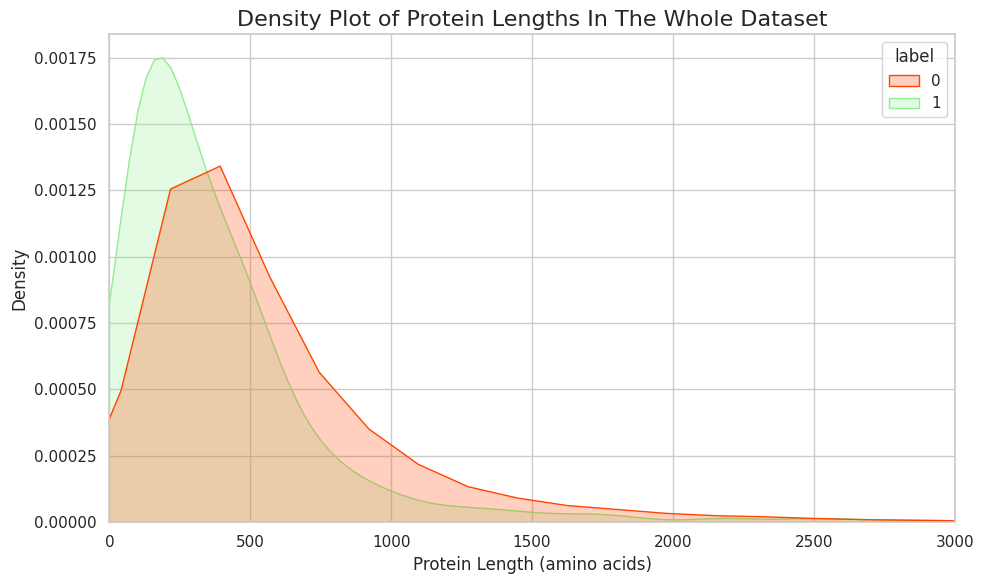

In [ ]:

# Set the style of the plot for better aesthetics
sns.set_style("whitegrid")

# Create the density plot using seaborn
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Protein_Length', hue='label', fill=True, common_norm=False, palette={1: 'lightgreen', 0: 'orangered'})

# Add a title and labels for clarity
plt.title('Density Plot of Protein Lengths In The Whole Dataset', fontsize=16)
plt.xlabel('Protein Length (amino acids)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Set x-axis limits to focus on the main distribution area
plt.xlim(0, 3000)

# Display the plot
plt.tight_layout() # Adjusts plot to prevent labels from being cut off
plt.savefig('plots/Density_Plot_of_Protein_Lengths_In_The_Whole_Dataset.png')
plt.show()

# Save the plot to the plots folder in the content


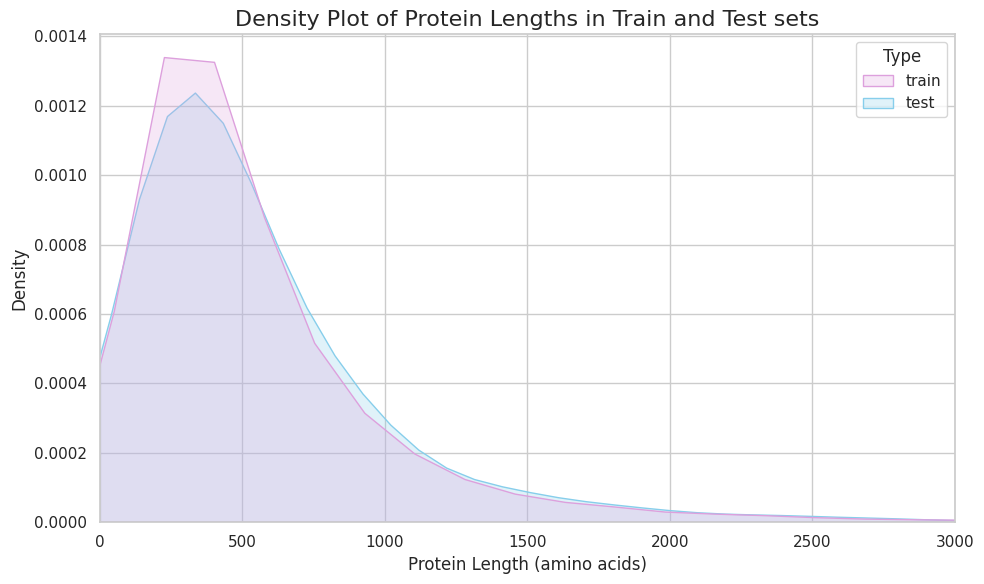

In [ ]:
# Density plots of protein lens between train and test


# Set the style of the plot for better aesthetics
sns.set_style("whitegrid")

# Create the density plot using seaborn
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Protein_Length', hue='Type', fill=True, common_norm=False, palette={"train": 'plum', "test": 'skyblue'})

# Add a title and labels for clarity
plt.title('Density Plot of Protein Lengths in Train and Test sets', fontsize=16)
plt.xlabel('Protein Length (amino acids)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Set x-axis limits to focus on the main distribution area
plt.xlim(0, 3000)

# Display the plot
plt.tight_layout() # Adjusts plot to prevent labels from being cut off

#save
plt.savefig('plots/Density_Plot_of_Protein_Lengths_in_Train_and_Test_sets.png')

plt.show()


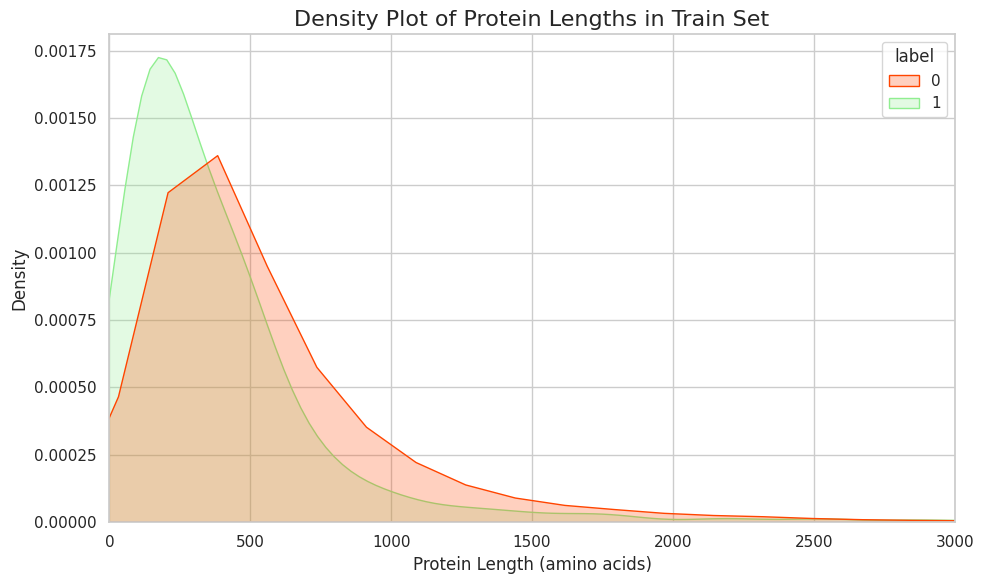

In [ ]:

# Set the style of the plot for better aesthetics
sns.set_style("whitegrid")

# Create the density plot using seaborn
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_train, x='Protein_Length', hue='label', fill=True, common_norm=False, palette={1: 'lightgreen', 0: 'orangered'})

# Add a title and labels for clarity
plt.title('Density Plot of Protein Lengths in Train Set', fontsize=16)
plt.xlabel('Protein Length (amino acids)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Set x-axis limits to focus on the main distribution area
plt.xlim(0, 3000)

# Display the plot
plt.tight_layout() # Adjusts plot to prevent labels from being cut off
#save
plt.savefig('plots/Density_Plot_of_Protein_Lengths_in_Train_Set.png')
plt.show()



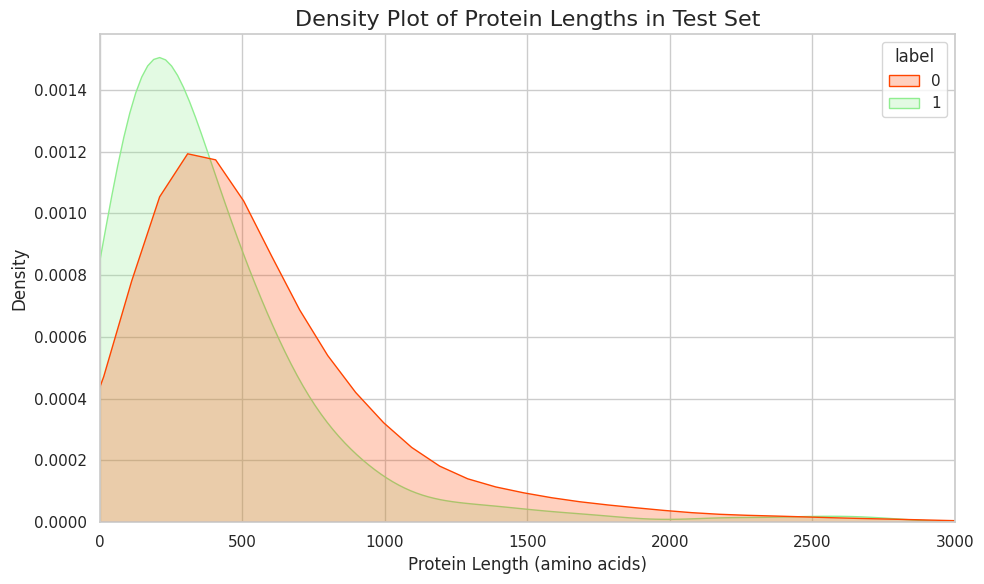

In [ ]:

# Set the style of the plot for better aesthetics
sns.set_style("whitegrid")

# Create the density plot using seaborn
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_test, x='Protein_Length', hue='label', fill=True, common_norm=False, palette={1: 'lightgreen', 0: 'orangered'})

# Add a title and labels for clarity
plt.title('Density Plot of Protein Lengths in Test Set', fontsize=16)
plt.xlabel('Protein Length (amino acids)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Set x-axis limits to focus on the main distribution area
plt.xlim(0, 3000)

# Display the plot
plt.tight_layout() # Adjusts plot to prevent labels from being cut off
#save
plt.savefig('plots/Density_Plot_of_Protein_Lengths_in_Test_Set.png')
plt.show()



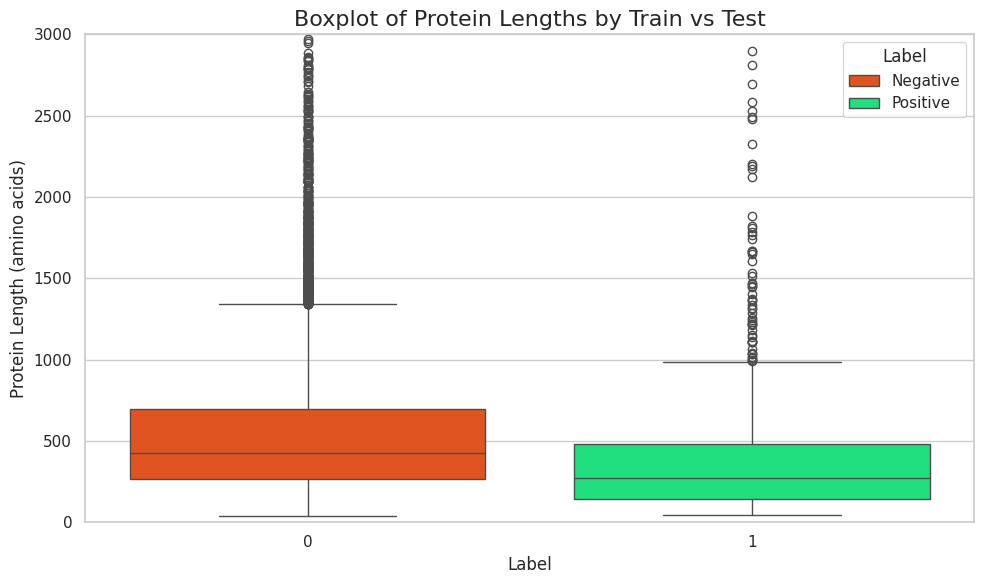

In [ ]:
# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="label",
    y="Protein_Length",
    hue="label",
    palette={1: 'springgreen', 0: 'orangered'}
)

# Add a title and labels for clarity
plt.title('Boxplot of Protein Lengths by Train vs Test', fontsize=16)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Protein Length (amino acids)', fontsize=12)
plt.legend(title='Label', labels=['Negative', 'Positive'])



plt.ylim(0, 3000) # Set y-axis limits to focus on main distribution

# Display the plot
plt.tight_layout()
#save
plt.savefig('plots/Boxplot_of_Protein_Lengths_by_Train_vs_Test.png')
plt.show()



## The distribution of SP lengths

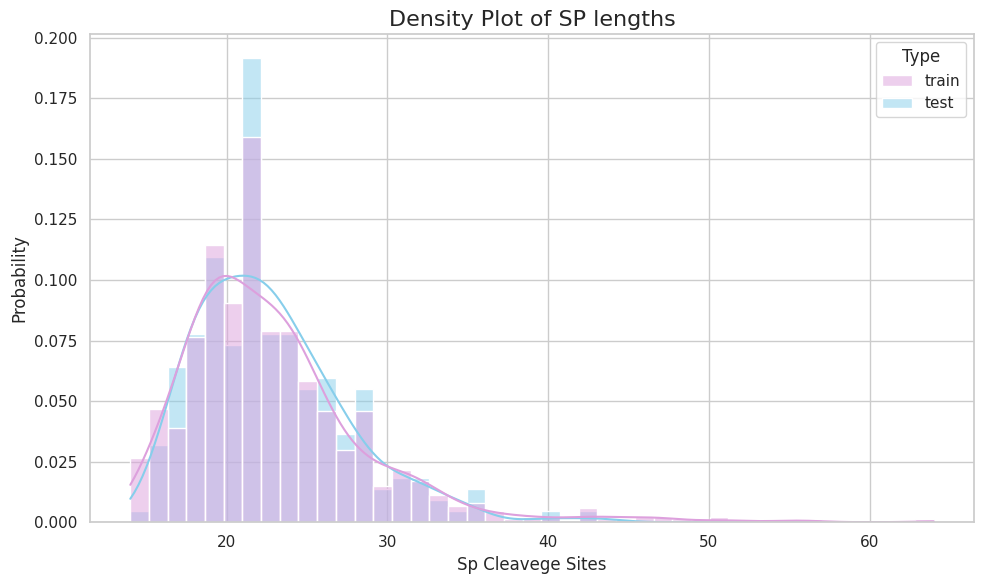

In [ ]:
# histogram using seaborn
plt.figure(figsize=(10, 6))
df_positive = df[df['label'] == 1]

sns.histplot(data=df_positive, x='Cleavage_Site', hue="Type", kde=True,  palette=["plum", "skyblue"], common_norm=False ,stat='probability')

# Add a title and labels for clarity
plt.title('Density Plot of SP lengths', fontsize=16)
plt.xlabel('Sp Cleavege Sites', fontsize=12)
#plt.ylabel('Density', fontsize=12)

# Display the plot
plt.tight_layout() # Adjusts plot to prevent labels from being cut off
#save
plt.savefig('plots/Probability_Plot_of_SP_lengths_of_Train_vs_Test.png')
plt.show()

## Comparative amino-acid composition of SPs against some background distribution
e.g. amino acid composition of SwissProt available at
https://web.expasy.org/docs/relnotes/relstat.html

- Display AA compositions of SP sequences and SwissProt using a combined barplot as
shown before

In [ ]:
# Background amino acid frequencies (from ExPASy)
aa_freq_expasy = {
    'A': 8.25, 'Q': 3.93, 'L': 9.64, 'S': 6.65, 'R': 5.52, 'E': 6.71,
    'K': 5.79, 'T': 5.36, 'N': 4.06, 'G': 7.07, 'M': 2.41, 'W': 1.1,
    'D': 5.46, 'H': 2.27, 'F': 3.86, 'Y': 2.92, 'C': 1.38, 'I': 5.9,
    'P': 4.74, 'V': 6.85
}

def compute_aa_freq(seq):
    """
    Compute normalized amino acid frequency (%) for a given sequence.
    Returns dict {aa: frequency}.
    """
    seq = seq.upper()
    counts = Counter(seq)
    total = sum(counts.values())
    return {aa: (counts.get(aa, 0) / total) * 100 for aa in aa_freq_expasy.keys()}

# Compute per-sequence amino acid frequencies
df_pos['aa_freq'] = df_pos['Sequence'].apply(compute_aa_freq)
df_neg['aa_freq'] = df_neg['Sequence'].apply(compute_aa_freq)

def average_freq(df_subset):
    freq_dicts = df_subset['aa_freq'].tolist()
    avg = {aa: sum(d[aa] for d in freq_dicts) / len(freq_dicts) for aa in aa_freq_expasy.keys()}
    return avg


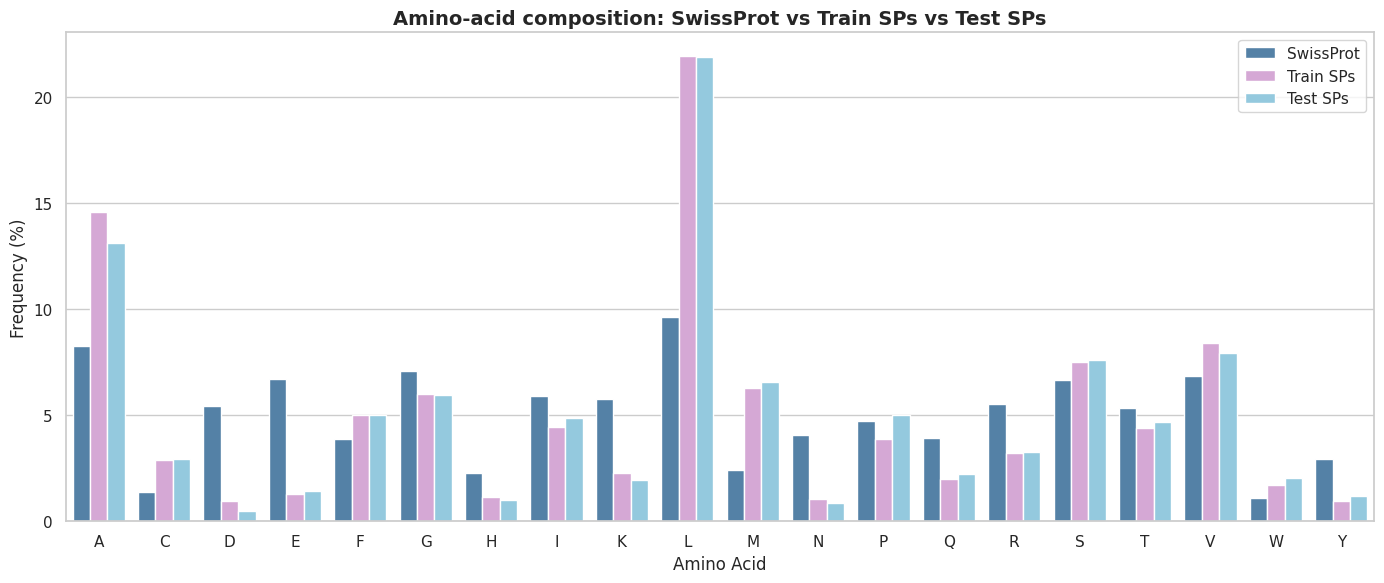

In [ ]:
# Standard AA order
aa_order = list("ACDEFGHIKLMNPQRSTVWY")

def sp_freq(df_subset):
    """Return AA frequencies (%) for SP region [:Cleavage_Site] in a subset."""
    sub = df_subset[(df_subset["label"] == 1) & df_subset["Cleavage_Site"].notna()].copy()
    sub["Cleavage_Site"] = sub["Cleavage_Site"].astype(int)
    sub = sub[sub["Cleavage_Site"] > 0]

    counts = Counter()
    total_len = 0
    for seq, cs in zip(sub["Sequence"], sub["Cleavage_Site"]):
        sp = str(seq).upper()[:cs]  # SP region
        keep = [aa for aa in sp if aa in aa_freq_expasy]
        counts.update(keep)
        total_len += len(keep)

    return {aa: (counts.get(aa, 0) / total_len) * 100 if total_len > 0 else 0.0 for aa in aa_order}

# Compute frequencies
train_freq = sp_freq(df[df["Type"] == "train"])
test_freq  = sp_freq(df[df["Type"] == "test"])

# Build one tidy DataFrame
df_plot = pd.DataFrame({
    "AA": aa_order * 3,
    "Percent": [aa_freq_expasy[a] for a in aa_order] +
               [train_freq[a] for a in aa_order] +
               [test_freq[a] for a in aa_order],
    "Source": ["SwissProt"] * 20 + ["Train SPs"] * 20 + ["Test SPs"] * 20
})

# Plot grouped barplot
plt.figure(figsize=(14, 6))
sns.barplot(data=df_plot, x="AA", y="Percent", hue="Source",
            palette={"SwissProt": "steelblue", "Train SPs": "plum", "Test SPs": "skyblue"})
plt.xlabel("Amino Acid", fontsize=12)
plt.ylabel("Frequency (%)", fontsize=12)
plt.title("Amino-acid composition: SwissProt vs Train SPs vs Test SPs", fontsize=14, fontweight="bold")
plt.legend(title=None, loc="upper right")
plt.tight_layout()
plt.savefig("plots/AA_Composition_SwissProt_Train_Test_grouped.png", dpi=300)
plt.show()


## Taxonomic classification

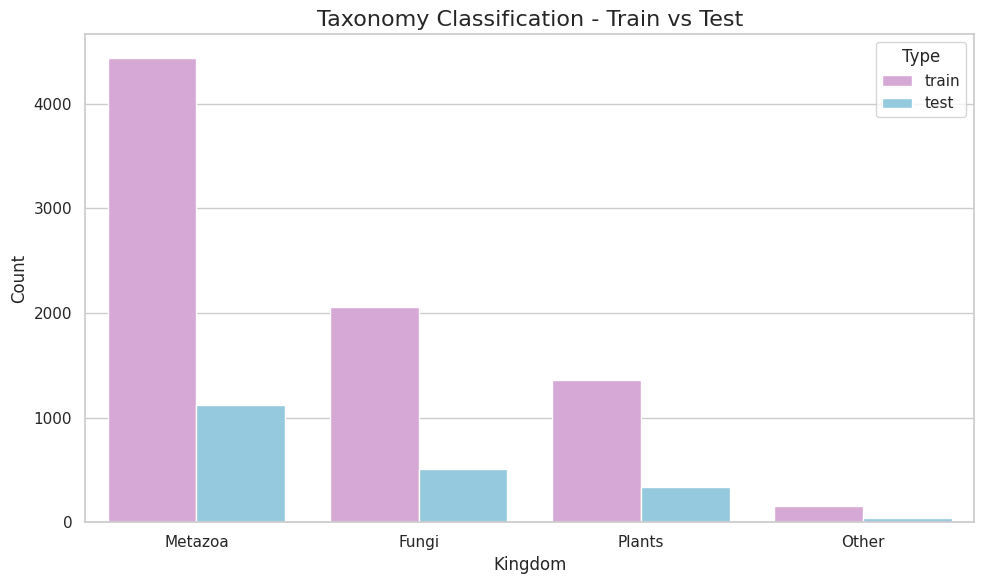

In [ ]:
# pie chart of Kingdom

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Kingdom', hue='Type', palette={"train": 'plum', "test": 'skyblue'})

# Add a title and labels for clarity
plt.title('Taxonomy Classification - Train vs Test', fontsize=16)
plt.xlabel('Kingdom', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Display the plot
plt.tight_layout() # Adjusts plot to prevent labels from being cut off
#save
plt.savefig('plots/Taxonomy_Classification_Train_vs_Test.png')
plt.show()



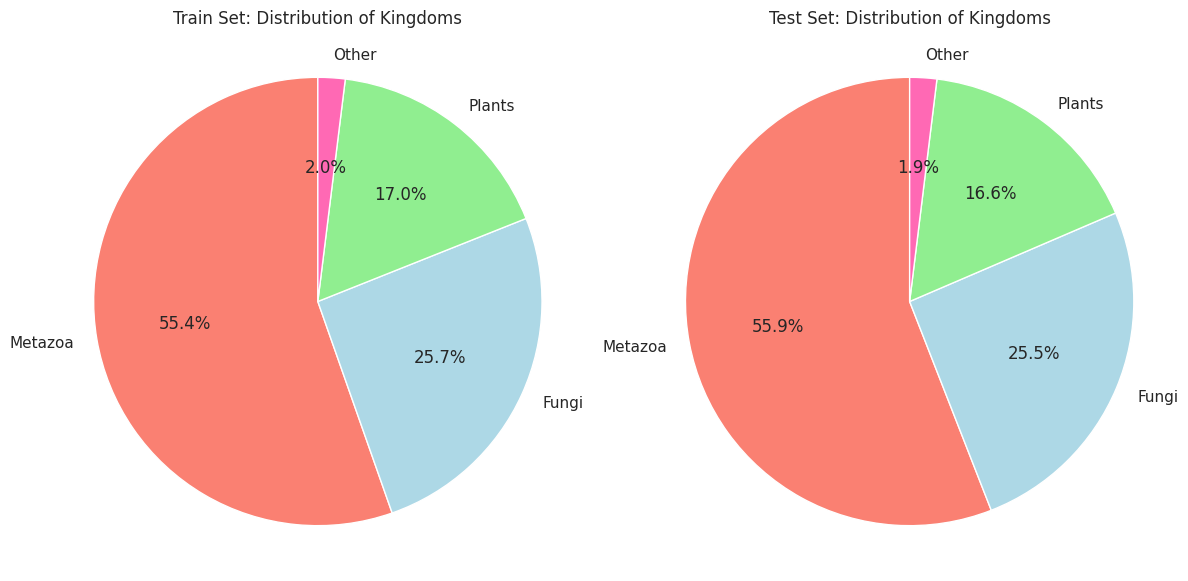

In [ ]:
# labels for kingdom but write with df[]
labels = df['Kingdom'].unique()
df_train_kingdom_n = df_train['Kingdom'].value_counts()
df_test_kingdom_n = df_test['Kingdom'].value_counts()
colors = ["salmon", "lightblue", "lightgreen", "hotpink"]

# plotting both pos and neg using pie

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
# Plot for positive data
axes[0].pie(df_train_kingdom_n, labels=df_train_kingdom_n.index, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Train Set: Distribution of Kingdoms')
axes[0].axis('equal')

# Plot for negative data
axes[1].pie(df_test_kingdom_n, labels=df_test_kingdom_n.index, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Test Set: Distribution of Kingdoms')
axes[1].axis('equal')

#save
plt.savefig('plots/Kingdom_Classification_Train_vs_Test.png')
plt.show()



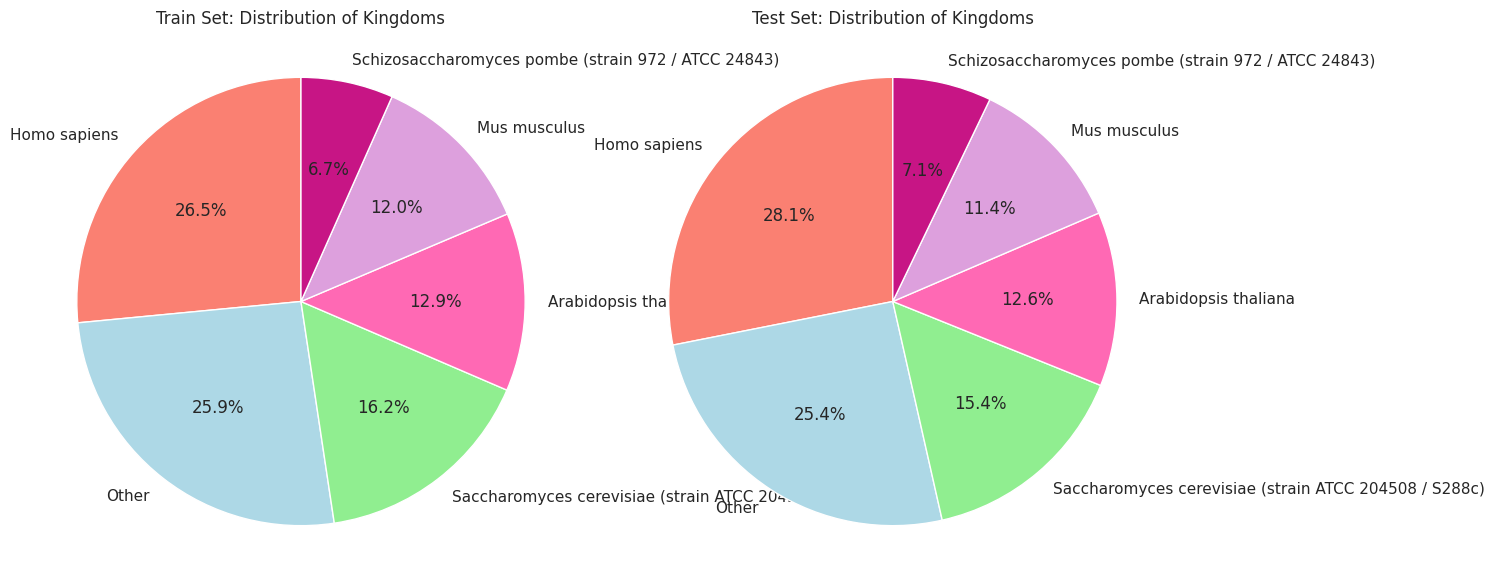

In [ ]:
# Create copies of the original dataframes for processing
df_train_processed = df_train.copy()
df_test_processed = df_test.copy()

# 1. Initial Organism Counts (using original df_train for the counts)
# Note: df is not modified, so we can keep the first line as is for labels.
labels = df['Organism'].unique()
df_train_organism_n = df_train_processed['Organism'].value_counts()
df_test_organism_n = df_test_processed['Organism'].value_counts()
colors = ["salmon", "lightblue", "lightgreen", "hotpink", "plum", "mediumvioletred"]

# set a threshold and change the name of the organisms below that to "Other"
threshold = 500

organisms_to_group = df_train_organism_n[df_train_organism_n < threshold].index

# 2. Apply grouping to the COPIED training set
df_train_processed.loc[df_train_processed['Organism'].isin(organisms_to_group), 'Organism'] = 'Other'


organisms_to_keep_train = df_train_processed['Organism'].unique() # Get the new labels from the modified train set

# 3. Apply grouping to the COPIED test set
# Group anything in the test set that is NOT one of the 'kept' train organisms
df_test_processed.loc[~df_test_processed['Organism'].isin(organisms_to_keep_train), 'Organism'] = 'Other'

# 4. Re-calculate value counts using the NEW processed dataframes
df_train_organism_n_new = df_train_processed['Organism'].value_counts()
df_test_organism_n_new = df_test_processed['Organism'].value_counts()

df_train_organism_n_new


### Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
# Plot for positive data
axes[0].pie(df_train_organism_n_new, labels=df_train_organism_n_new.index, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Train Set: Distribution of Kingdoms')
axes[0].axis('equal')

# Plot for negative data
axes[1].pie(df_test_organism_n_new, labels=df_test_organism_n_new.index, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Test Set: Distribution of Kingdoms')
axes[1].axis('equal')

#save
plt.savefig('plots/Organism_Classification_Train_vs_Test.png')
plt.show()

##  Sequence logos of SP cleavage sites

In [ ]:
#extract motifs from the df

motifs = []

### TODO: instead of df_pos, do 2 logos for training and test
  for index, row in df_pos.iterrows():
    sequence = row['Sequence']
    cleavage_site = row['Cleavage_Site']

    cleavage_site_python_index = int(cleavage_site) - 1
    motif = sequence[cleavage_site_python_index - 13: cleavage_site_python_index + 2]
    motifs.append(motif)

# write motifs to a txt.
with open('motifs.txt', 'w') as f:
    for motif in motifs:
        f.write(f"{motif}\n")


In [ ]:

"""
from google.colab import files
from IPython.display import Image

uploaded = files.upload()
Image('seq logo.png')

"""


"\nfrom google.colab import files\nfrom IPython.display import Image\n\nuploaded = files.upload()\nImage('seq logo.png')\n\n"

In [ ]:
!zip -r /content/plots.zip /content/plots

from google.colab import files
files.download("/content/plots.zip")



  adding: content/plots/ (stored 0%)
  adding: content/plots/Kingdom_Classification_Train_vs_Test.png (deflated 8%)
  adding: content/plots/Density_Plot_of_Protein_Lengths_in_Train_and_Test_sets.png (deflated 10%)
  adding: content/plots/Probability_Plot_of_SP_lengths_of_Train_vs_Test.png (deflated 10%)
  adding: content/plots/Organism_Classification_Train_vs_Test.png (deflated 8%)
  adding: content/plots/Density_Plot_of_Protein_Lengths_In_The_Whole_Dataset.png (deflated 10%)
  adding: content/plots/Taxonomy_Classification_Train_vs_Test.png (deflated 23%)
  adding: content/plots/AA_Composition_SwissProt_Train_Test_grouped.png (deflated 33%)
  adding: content/plots/Density_Plot_of_Protein_Lengths_in_Train_Set.png (deflated 10%)
  adding: content/plots/Boxplot_of_Protein_Lengths_by_Train_vs_Test.png (deflated 15%)
  adding: content/plots/Density_Plot_of_Protein_Lengths_in_Test_Set.png (deflated 9%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Part D: Model Creation (von Heijne)

1) First we have aligned/stacked seq fragments
2) We turn this into Position Specific Probability Matrix (PSPM). Freq of each aa at each position
3) From freq, create Position-Specific Weight Matrix (PSWM): log-odds
between frequencies in the PSPM and some
background model (e.g., the SwissProt composition)

In [ ]:
# Structure of the code should be:

# Two functions:

# 1) Training:
#    inputs: training (only positive data) and validation (positive and negative data) sets
#    output: W matrix, and estimated threshold
#    - estimation of the matrix W
#    - predict scores for validation data (W)
#    - estimate the threshold using scores, classes, PR-curse(?)

# 2) Prediction:
#    inputs: testing (positive and negative), W matrix, threshold
#    output: classification
#    - predict the scores for testing data
#    - use the treshold to transform scores into 0/1 classes

# the prediction part of both functions might be done a single external function
# the standard error can be reported in the end: value +/- SE





1. Starting 5-fold cross-validation...
  - Run 1/5: Test Fold: 0, Validation Fold: 1, Training Folds: [2, 3, 4]
  - Run 2/5: Test Fold: 1, Validation Fold: 2, Training Folds: [0, 3, 4]
  - Run 3/5: Test Fold: 2, Validation Fold: 3, Training Folds: [0, 1, 4]
  - Run 4/5: Test Fold: 3, Validation Fold: 4, Training Folds: [0, 1, 2]
  - Run 5/5: Test Fold: 4, Validation Fold: 0, Training Folds: [1, 2, 3]

2. Cross-Validation Final Performance Metrics:
| Metric                    | Value           |
|---------------------------|-----------------|
| F1 Score (Mean ± SE)      | 0.7240 ± 0.0159 |
| Precision (Mean ± SE)     | 0.7503 ± 0.0140 |
| Recall (Mean ± SE)        | 0.7061 ± 0.0345 |
| Avg Threshold (Mean ± SE) | 6.7312 ± 0.1567 |
| MCC (Mean ± SE)           | 0.6942 ± 0.0158 |

3. Generating and saving averaged Precision-Recall curve plot...
Plot saved as 'averaged_precision_recall_curve.png'


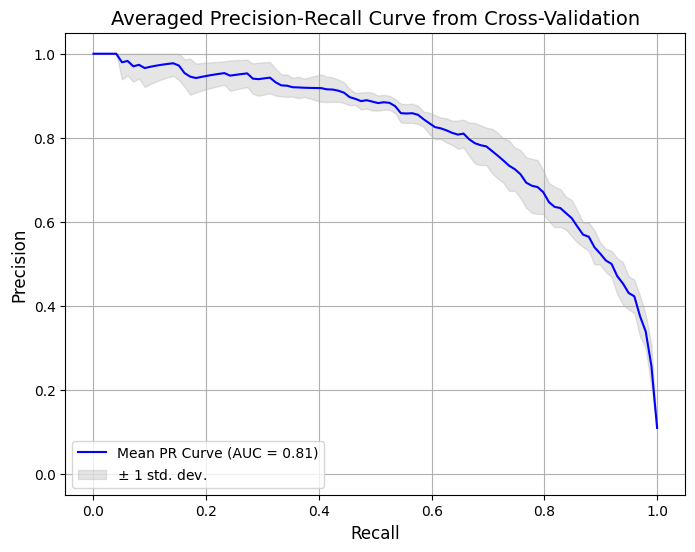


5. Generating and saving PSWM Heatmap...
Heatmap saved as 'pswm_heatmap.png'


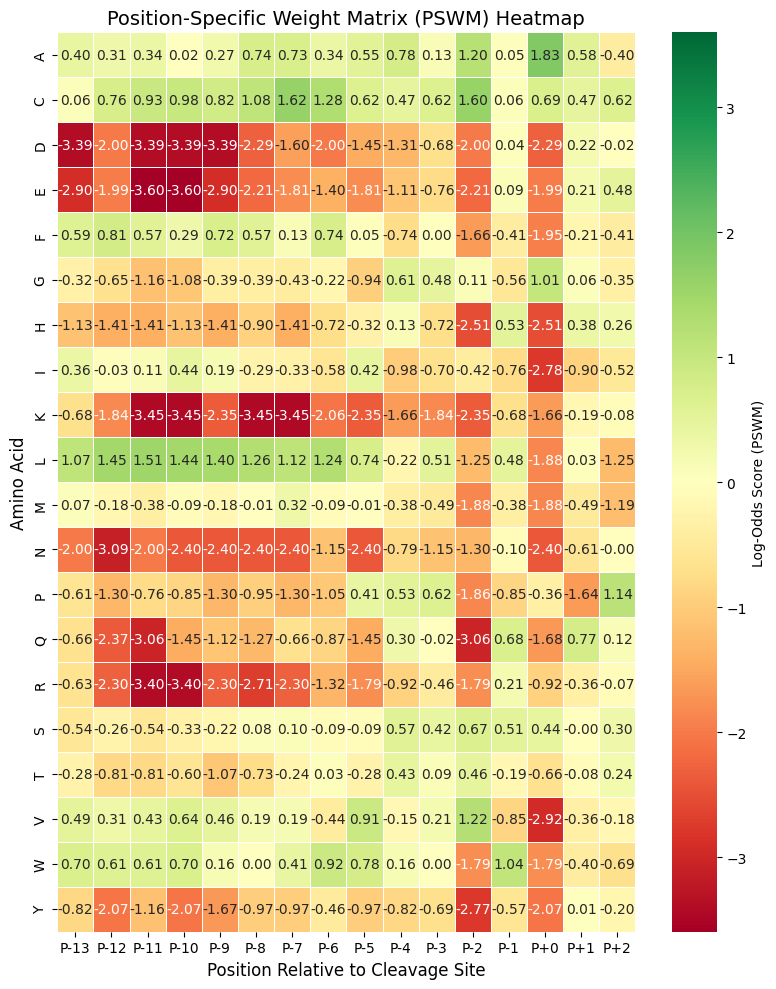

In [ ]:
from typing import final
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score, matthews_corrcoef
import matplotlib.pyplot as plt
from numpy import trapezoid
import seaborn as sns
from tabulate import tabulate



# Constants
WINDOW_START = -13
WINDOW_END = 2
WINDOW_SIZE = WINDOW_END - WINDOW_START + 1
PSEUDOCOUNT = 1
SCAN_REGION = 90
AMINO_ACIDS = 'ACDEFGHIKLMNPQRSTVWY'
aa_freq_expasy = {
    'A': 8.25, 'R': 5.52, 'N': 4.06, 'D': 5.46, 'C': 1.38, 'Q': 3.93,
    'E': 6.71, 'G': 7.07, 'H': 2.27, 'I': 5.9,  'L': 9.64, 'K': 5.79,
    'M': 2.41, 'F': 3.86, 'P': 4.74, 'S': 6.65, 'T': 5.36, 'W': 1.1,
    'Y': 2.92, 'V': 6.85
}
background_frequencies = {aa: freq / 100.0 for aa, freq in aa_freq_expasy.items()}


# Rest of the thing 💠 🏮 🍨 🛡 📞 💾 📈 💐 🍉 ▶️ 🛢 🐢 ⚰ 👼 🎷 🚾 🕑 👪 🌬 🔊 😄 👅 🎭 🚟 🦃 🐃 🐳 🍩 🎰 ✌️

def predict_scores(data_df, score_matrix):
    """Calculates scores for each sequence."""
    all_scores = []
    for _, row in data_df.iterrows():
        seq = row["Sequence"]
        max_score = float('-inf')
        scan_limit = min(len(seq), SCAN_REGION) - WINDOW_SIZE + 1

        for i in range(scan_limit):
            window = seq[i : i + WINDOW_SIZE]
            if len(window) == WINDOW_SIZE and all(aa in AMINO_ACIDS for aa in window):
                current_score = sum(score_matrix[aa][pos] for pos, aa in enumerate(window))
                if current_score > max_score:
                    max_score = current_score
        all_scores.append(max_score if max_score != float('-inf') else -999)
    return all_scores


def plot_pswm_heatmap(pswm):
    """
    Generates a heatmap of the PSWM with high (positive) values as green
    and low (negative) values as red.
    """
    print("\n5. Generating and saving PSWM Heatmap...")

    pswm_df = pd.DataFrame(pswm).T
    window_cols = [f'P{i:+d}' for i in range(WINDOW_START, WINDOW_END + 1)]
    pswm_df.columns = window_cols

    vmax = pswm_df.abs().max().max()
    vmin = -vmax

    plt.figure(figsize=(WINDOW_SIZE * 0.5, len(AMINO_ACIDS) * 0.5))

    # 3. Create the heatmap
    sns.heatmap(
        pswm_df,
        cmap='RdYlGn',
        vmin=vmin,
        vmax=vmax,
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=.5,
        cbar_kws={'label': 'Log-Odds Score (PSWM)'}
    )

    plt.title('Position-Specific Weight Matrix (PSWM) Heatmap', fontsize=14)
    plt.xlabel('Position Relative to Cleavage Site', fontsize=12)
    plt.ylabel('Amino Acid', fontsize=12)

    plt.tight_layout()
    plt.savefig('pswm_heatmap.png', dpi=300)
    print("Heatmap saved as 'pswm_heatmap.png'")
    plt.show()



def training(train_df, val_df):
    """
    Trains the PSWM and finds the best threshold.

    """
    # Get all the motifs from positive seqs to train matrix
    motifs = []
    for _, row in train_df[train_df["label"] == 1].iterrows():
        cs = int(row['Cleavage_Site']) - 1
        motif = row["Sequence"][cs + WINDOW_START : cs + WINDOW_END + 1]
        if len(motif) == WINDOW_SIZE:
            motifs.append(motif)

    #Create Matrix
    score_matrix = {aa: [PSEUDOCOUNT] * WINDOW_SIZE for aa in AMINO_ACIDS}
    for motif in motifs:
        for i, aa in enumerate(motif):
            if aa in score_matrix: score_matrix[aa][i] += 1

    n = len(motifs)
    divisor = n + len(AMINO_ACIDS)
    pspm = {aa: [count / divisor for count in score_matrix[aa]] for aa in AMINO_ACIDS}
    pswm = {aa: [np.log(pspm[aa][i] / background_frequencies[aa]) for i in range(WINDOW_SIZE)] for aa in AMINO_ACIDS}

    ### Finding a threshold
    y_validation_true = val_df["label"].tolist()
    y_validation_scores = predict_scores(val_df, pswm)

    precision, recall, thresholds = precision_recall_curve(y_validation_true, y_validation_scores)
    fscore = (2 * precision * recall) / (precision + recall + 1e-9)
    optimal_threshold = thresholds[np.argmax(fscore)]

    #Return the precision, recall for later plotting
    return pswm, optimal_threshold, precision, recall


def prediction(test_df, score_matrix, threshold):
    """Predicts labels for the test set."""
    test_scores = predict_scores(test_df, score_matrix)
    return [1 if score >= threshold else 0 for score in test_scores]


def plot_averaged_pr_curve(all_precisions, all_recalls):
    """
    Takes lists of precision and recall arrays from a CV run and plots the averaged curve.
    """
    print("\n3. Generating and saving averaged Precision-Recall curve plot...")

    # Interpolate all curves to a common recall axis
    mean_recall_axis = np.linspace(0, 1, 100)
    interpolated_precisions = []
    for recall, precision in zip(all_recalls, all_precisions):
        recall_increasing = recall[::-1]
        precision_increasing = precision[::-1]
        interp_precision = np.interp(mean_recall_axis, recall_increasing, precision_increasing)
        interpolated_precisions.append(interp_precision)

    interpolated_precisions = np.array(interpolated_precisions)

    # Calculate mean and standard deviation
    mean_precision_curve = np.mean(interpolated_precisions, axis=0)
    std_precision = np.std(interpolated_precisions, axis=0)
    pr_auc = trapezoid(mean_precision_curve, mean_recall_axis)

    # Generate the plot using your specified design
    plt.figure(figsize=(8, 6))
    plt.plot(mean_recall_axis, mean_precision_curve, color='b',
              label=fr'Mean PR Curve (AUC = {pr_auc:.2f})')

    tprs_upper = np.minimum(mean_precision_curve + std_precision, 1)
    tprs_lower = np.maximum(mean_precision_curve - std_precision, 0)
    plt.fill_between(mean_recall_axis, tprs_lower, tprs_upper, color='grey', alpha=.2,
                      label=r'$\pm$ 1 std. dev.')

    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Averaged Precision-Recall Curve from Cross-Validation', fontsize=14)
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.savefig('averaged_precision_recall_curve.png', dpi=300)
    print("Plot saved as 'averaged_precision_recall_curve.png'")
    plt.show()

def main(df):
    """
    Runs cross-validation, reports performance, and generates the averaged PR plot.
    """
    all_f1_scores, all_precision_scores, all_recall_scores, all_mcc_scores = [], [], [], []

    # Vars for plot
    pr_curve_precisions = []
    pr_curve_recalls = []
    all_thres = []

    print("1. Starting 5-fold cross-validation...")
    for j in range(5):
        test_index, validation_index = j, (j + 1) % 5
        training_indices = [k for k in range(5) if k not in {test_index, validation_index}]

        print(f"  - Run {j+1}/5: Test Fold: {test_index}, Validation Fold: {validation_index}, Training Folds: {training_indices}")

        test_df = df[df["fold"] == test_index]
        validation_df = df[df["fold"] == validation_index]
        training_df = df[df["fold"].isin(training_indices)]

        pswm, threshold, fold_precision, fold_recall = training(training_df, validation_df)
        all_thres.append(threshold)

        pr_curve_precisions.append(fold_precision)
        pr_curve_recalls.append(fold_recall)

        y_pred = prediction(test_df, pswm, threshold)
        y_true = test_df["label"].tolist()

        all_f1_scores.append(f1_score(y_true, y_pred, zero_division=0))
        all_precision_scores.append(precision_score(y_true, y_pred, zero_division=0))
        all_recall_scores.append(recall_score(y_true, y_pred, zero_division=0))
        all_mcc_scores.append(matthews_corrcoef(y_true, y_pred))

    ### Calculate the metrics
    #f1
    mean_f1 = np.mean(all_f1_scores)
    se_f1 = np.std(all_f1_scores) / np.sqrt(5)
    final_f1 = f"{mean_f1:.4f} ± {se_f1:.4f}"

    #precision
    mean_precision = np.mean(all_precision_scores)
    se_precision = np.std(all_precision_scores) / np.sqrt(5)
    final_precision = f"{mean_precision:.4f} ± {se_precision:.4f}"

    #recall
    mean_recall = np.mean(all_recall_scores)
    se_recall = np.std(all_recall_scores) / np.sqrt(5)
    final_recall = f"{mean_recall:.4f} ± {se_recall:.4f}"

    #mcc
    mean_mcc = np.mean(all_mcc_scores)
    se_mcc = np.std(all_mcc_scores) / np.sqrt(5)
    final_mcc = f"{mean_mcc:.4f} ± {se_mcc:.4f}"

    #avg threshold
    mean_threshold = np.mean(all_thres)
    se_threshold = np.std(all_thres) / np.sqrt(5)
    final_threshold = f"{mean_threshold:.4f} ± {se_threshold:.4f}"

    table_data = [
        ("F1 Score (Mean ± SE)", final_f1),
        ("Precision (Mean ± SE)", final_precision),
        ("Recall (Mean ± SE)", final_recall),
        ("Avg Threshold (Mean ± SE)", final_threshold),
        ("MCC (Mean ± SE)", final_mcc),
    ]

    # 2. Define the headers
    headers = ["Metric", "Value"]

    # 3. Print the title and the table
    print("\n2. Cross-Validation Final Performance Metrics:")

    # 'grid' format provides a clean, box-style table
    print(tabulate(table_data, headers=headers, tablefmt="github"))

    #save the table
    with open("cross_validation_results.txt", "w") as f:
        f.write(tabulate(table_data, headers=headers, tablefmt="github"))


    # PLot PR curve
    plot_averaged_pr_curve(pr_curve_precisions, pr_curve_recalls)

    #Plot the heatmap of matrix
    plot_pswm_heatmap(pswm)

if __name__ == "__main__":
  input_tsv = "merged_dataset_with_seqs.tsv"

  df = pd.read_csv(input_tsv, sep="\t")
  main(df)

In [ ]:
# Pretty print the PSWM
print("\n4. Final Position-Specific Weight Matrix (PSWM):")
pswm_df = pd.DataFrame(pswm).T
window_cols = [f'P{i:+d}' for i in range(WINDOW_START, WINDOW_END + 1)]
pswm_df.columns = window_cols
print(pswm_df.round(decimals=4).to_string())


A
D
E
K


# Feature Selection

TODO: In the final report he wants "minimal feature set"???
the idea is to improve the performance. if feature set is becoming too large use
random forest etc. (automatic). Otherwise try to use the manual ones

Feature selection methods :

1) Filter: Looking at features manually.

    - Checking for varience, correlation, Chi square, and more (check the slides)

2) Wrapper: Uses external algo to get feat ranking. Recursively eliminate non relevant or add relevant feats.
    - Logistic regression (linear models),

3) Embedded: Completely embed feat selection process into the final model like SVM.
    - Random Forest (gini impurity importance)

# Part E: SVM

I think we should use `probability = True`

we can extend the approach with additional things but we need to create a baseline feature set. Maye use data visuals and get info from there to decide on feats.


1) we can exploit sp length dist and aa freqs.
    - We can encode each protein by the composition of its n-terminus. Basically looking at the start of the seq in the context of aa freqs.
    - Each protein is encoded with a 20 dimensional vector based on aa freq.
    - This will be the baseline feature
2) additional features:
    - hydrophobicity, charge, propensity to form secondary structures/transmembrane helix,


**Practical session IV**

Implement the SVM-based approach using sklearn

-  AA composition feature computed over the first 22 residues
-  Hydrophobicity feature
-  Other features (must be defined)
-  Feature selection = RandomForest
-  Kernel function: test different kernel functions
-  Hyperparameter optimization (C, kernel, kernel parameters etc…) using cross-validation
and grid-search

In [ ]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

--- 1. Loading and Preparing Data ---
Dataset loaded successfully.
Training set size: 8021
Test set size: 2006

--- 2. Engineering Augmented Features based on Signal Peptide Biology ---
Training feature engineering complete. Shape: (8021, 26)
Test feature engineering complete. Shape: (2006, 26)

--- 3. Running Feature Selection with RandomForest ---


/tmp/ipython-input-3339182881.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis_r')


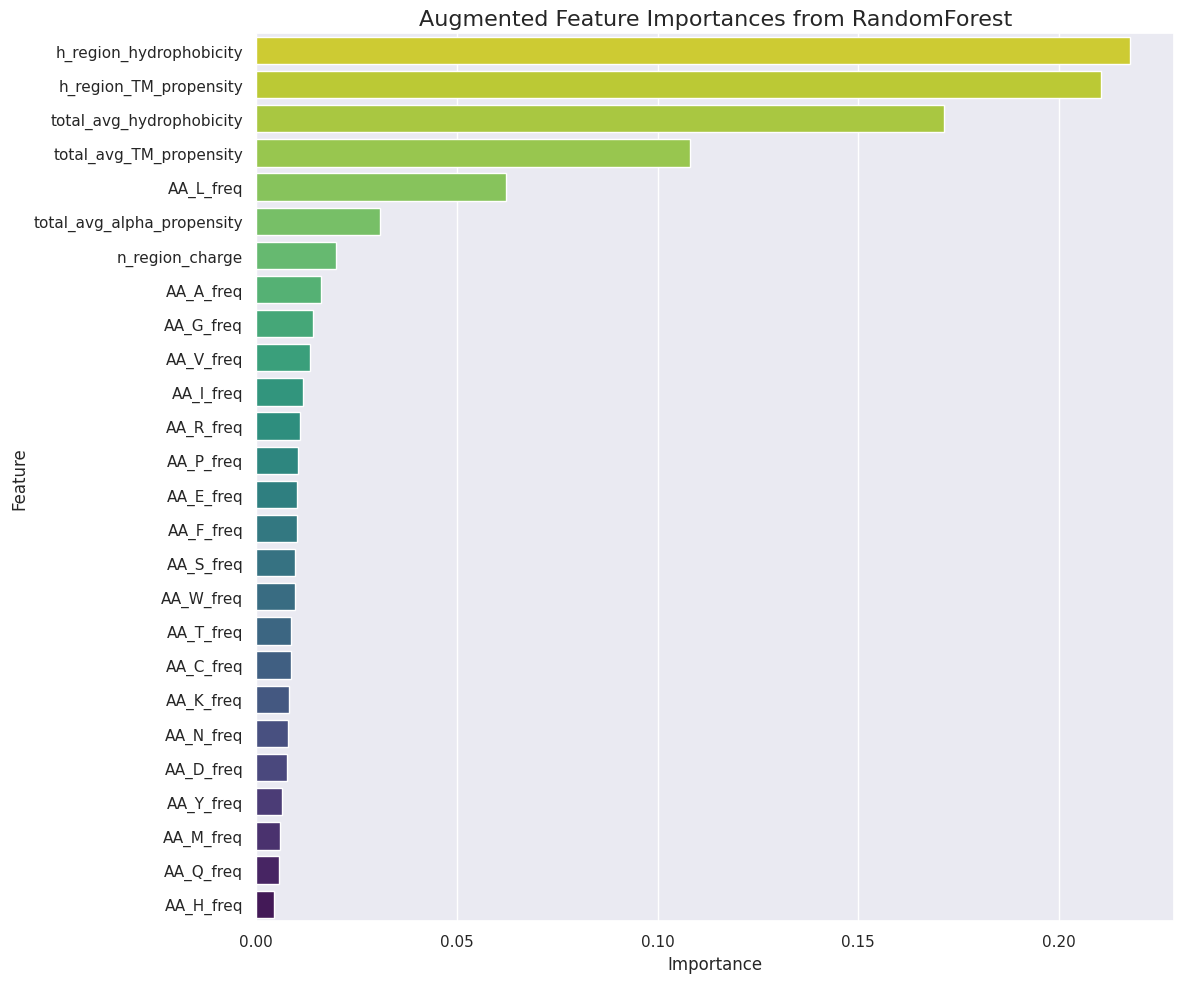

Top 15 most important features:
                        Feature  Importance
21     h_region_hydrophobicity    0.217849
22      h_region_TM_propensity    0.210616
23    total_avg_hydrophobicity    0.171390
24     total_avg_TM_propensity    0.107980
9                    AA_L_freq    0.062189
25  total_avg_alpha_propensity    0.030830
20             n_region_charge    0.019950
0                    AA_A_freq    0.016001
5                    AA_G_freq    0.014200
17                   AA_V_freq    0.013311
7                    AA_I_freq    0.011722
14                   AA_R_freq    0.010870
12                   AA_P_freq    0.010280
3                    AA_E_freq    0.010224
4                    AA_F_freq    0.010195

--- 4. Optimizing SVM Hyperparameters with GridSearchCV ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits

GridSearchCV complete.
Best parameters found: {'C': 0.1, 'kernel': 'linear'}
Best cross-validation F1-score: 0.8412

--- 5. Evaluating the Best Model on th

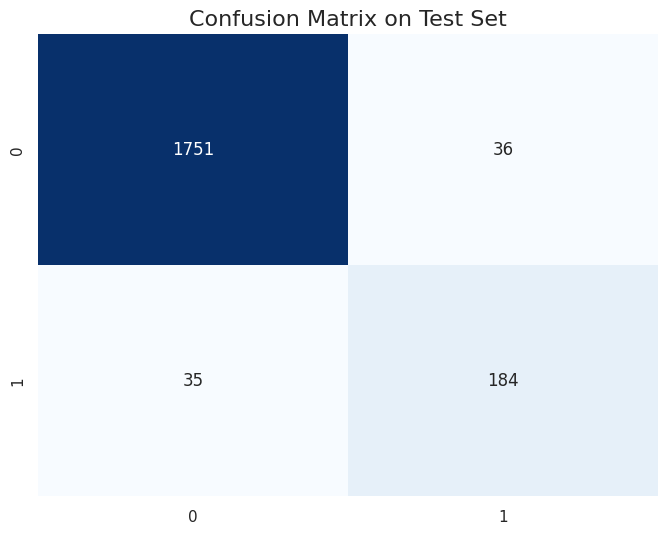

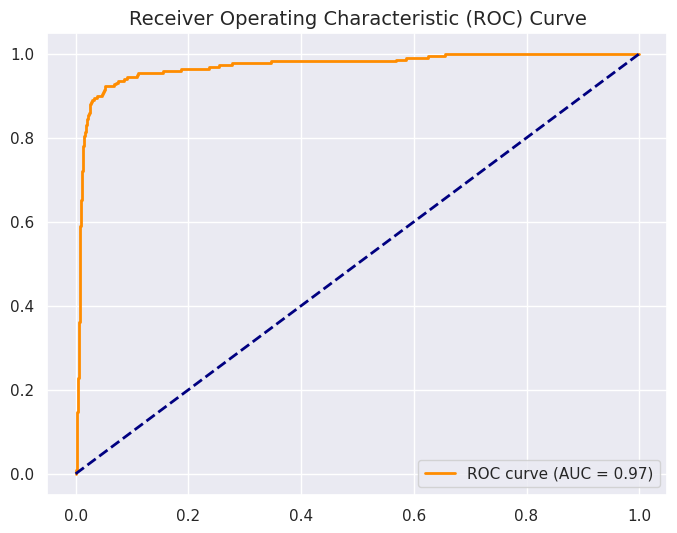


--- 6. Saving the final trained model and scaler to disk ---
Successfully saved the trained SVM model to: svm_signal_peptide_model.joblib
Successfully saved the feature scaler to: feature_scaler.joblib

Script for Practical Session IV finished successfully.


In [ ]:
# LB2 Project: Support Vector Machine for Signal Peptide Detection
# Practical Session IV
#
# This script implements a complete machine learning pipeline to classify proteins
# based on the presence of a signal peptide (SP).
#
# The pipeline includes:
# 1. Loading data with predefined cross-validation folds.
# 2. Engineering a rich set of features based on the physicochemical properties
#    of the N-terminal sequence.
# 3. Applying feature selection using a RandomForestClassifier to rank features.
# 4. Performing hyperparameter optimization for an SVM classifier using GridSearchCV.
# 5. Evaluating the final, optimized model.
# 6. Saving the trained model and the feature scaler to disk for future use.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import joblib # Import the joblib library for saving the model

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Set plot style for consistency
sns.set_theme(context="notebook", style="darkgrid", palette="muted")

# --- 1. Data Loading and Preparation ---
print("--- 1. Loading and Preparing Data ---")
try:
    df = pd.read_csv("merged_dataset_with_seqs.tsv", sep="\t")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'merged_dataset_with_seqs.tsv' not found.")
    exit()

train_df = df[df["Type"] == "train"].copy()
test_df = df[df["Type"] == "test"].copy()
print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")


# --- 2. Feature Engineering (Augmented Features) ---
print("\n--- 2. Engineering Augmented Features based on Signal Peptide Biology ---")
AMINO_ACIDS = sorted(list("ACDEFGHIKLMNPQRSTVWY"))
N_TERMINUS_LEN = 22
HYDROPHOBICITY_SCALE_KD = {
    'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5, 'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5, 'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6, 'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
}
TM_HELIX_PROPENSITY_SCALE = {
    'A': 0.25, 'R': -1.80, 'N': -0.64, 'D': -0.72, 'C': 0.04, 'Q': -0.69, 'E': -0.62, 'G': 0.16, 'H': -0.40, 'I': 0.73, 'L': 0.53, 'K': -1.10, 'M': 0.26, 'F': 0.61, 'P': -0.07, 'S': -0.26, 'T': -0.18, 'W': 0.37, 'Y': 0.02, 'V': 0.54
}
ALPHA_HELIX_PROPENSITY = {
    'A': 1.42, 'R': 0.98, 'N': 0.67, 'D': 1.01, 'C': 0.70, 'Q': 1.11, 'E': 1.51, 'G': 0.57, 'H': 1.00, 'I': 1.08, 'L': 1.21, 'K': 1.16, 'M': 1.45, 'F': 1.13, 'P': 0.57, 'S': 0.77, 'T': 0.83, 'W': 1.08, 'Y': 0.69, 'V': 1.06
}
CHARGE_SCALE = {'D': -1, 'E': -1, 'K': 1, 'R': 1}

def calculate_average_property(sequence, scale):
    if not sequence: return 0.0
    return sum(scale.get(aa, 0.0) for aa in sequence) / len(sequence)

def create_augmented_features(sequence):
    if not isinstance(sequence, str): sequence = ""
    n_term_seq = sequence[:N_TERMINUS_LEN].upper()
    n_region, h_region = n_term_seq[0:5], n_term_seq[5:16]
    if not n_term_seq: return [0.0] * (len(AMINO_ACIDS) + 6)
    counts, total_len = Counter(n_term_seq), len(n_term_seq)
    aa_composition = [(counts.get(aa, 0) / total_len) for aa in AMINO_ACIDS]
    n_region_charge = sum(CHARGE_SCALE.get(aa, 0) for aa in n_region)
    h_region_hydrophobicity_kd = calculate_average_property(h_region, HYDROPHOBICITY_SCALE_KD)
    h_region_propensity_tm = calculate_average_property(h_region, TM_HELIX_PROPENSITY_SCALE)
    avg_hydrophobicity_total = calculate_average_property(n_term_seq, HYDROPHOBICITY_SCALE_KD)
    avg_propensity_tm_total = calculate_average_property(n_term_seq, TM_HELIX_PROPENSITY_SCALE)
    avg_propensity_alpha_total = calculate_average_property(n_term_seq, ALPHA_HELIX_PROPENSITY)
    return aa_composition + [n_region_charge, h_region_hydrophobicity_kd, h_region_propensity_tm, avg_hydrophobicity_total, avg_propensity_tm_total, avg_propensity_alpha_total]


X_train_list = train_df['Sequence'].apply(create_augmented_features).tolist()
y_train = train_df['label'].values
X_train = np.array(X_train_list)
feature_names = ([f"AA_{aa}_freq" for aa in AMINO_ACIDS] + ["n_region_charge", "h_region_hydrophobicity", "h_region_TM_propensity", "total_avg_hydrophobicity", "total_avg_TM_propensity", "total_avg_alpha_propensity"])
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
print(f"Training feature engineering complete. Shape: {X_train_scaled.shape}")


if not test_df.empty:
    X_test_list = test_df['Sequence'].apply(create_augmented_features).tolist()
    y_test = test_df['label'].values
    X_test = np.array(X_test_list)
    X_test_scaled = scaler.transform(X_test)
    print(f"Test feature engineering complete. Shape: {X_test_scaled.shape}")
else:
    X_test_scaled, y_test = np.array([]), np.array([])


# --- 3. Feature Selection using RandomForest ---
print("\n--- 3. Running Feature Selection with RandomForest ---")
rf_selector = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_scaled, y_train)
importances = rf_selector.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 10))

sns.barplot(x='Importance', y='Feature', data=feature_importance_df,
            hue='Feature', palette='viridis_r', legend=False)

plt.title('Augmented Feature Importances from RandomForest', fontsize=16)
plt.tight_layout()
plt.savefig("svm_augmented_feature_importances.png", dpi=300)
plt.show()
print("Top 15 most important features:\n", feature_importance_df.head(15).to_string())


# --- 4. SVM Hyperparameter Optimization with GridSearchCV ---
print("\n--- 4. Optimizing SVM Hyperparameters with GridSearchCV ---")

# This results in 36 = (4 + (4*4) + (4*2*2)) combinations of parameters, we will
# test which is best over 5 folds
param_grid_nested = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.1]},
    {'kernel': ['poly'], 'C': [0.1, 1, 10, 100], 'degree': [2, 3], 'gamma': ['scale', 'auto']}
]


cv_iterator = []
index_mapper = {original_idx: array_idx for array_idx, original_idx in enumerate(train_df.index)}
for i in range(5):
    train_fold_indices = train_df[train_df['fold'] != i].index
    val_fold_indices = train_df[train_df['fold'] == i].index
    train_indices_mapped = [index_mapper[idx] for idx in train_fold_indices]
    val_indices_mapped = [index_mapper[idx] for idx in val_fold_indices]
    cv_iterator.append((train_indices_mapped, val_indices_mapped))


grid_search = GridSearchCV(estimator=SVC(probability=True, random_state=42), param_grid=param_grid_nested, cv=cv_iterator, scoring='f1', n_jobs=-1, verbose=2)
grid_search.fit(X_train_scaled, y_train)
best_svm = grid_search.best_estimator_
print("\nGridSearchCV complete.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")


# --- 5. Final Model Evaluation on the Test Set ---
print("\n--- 5. Evaluating the Best Model on the Hold-out Test Set ---")
if X_test_scaled.shape[0] > 0:
    y_pred = best_svm.predict(X_test_scaled)
    y_pred_proba = best_svm.predict_proba(X_test_scaled)[:, 1]
    print("\nClassification Report on Test Set:")
    print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix on Test Set', fontsize=16)
    plt.savefig("svm_confusion_matrix.png", dpi=300)
    plt.show()
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.grid(True)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
    plt.legend(loc="lower right")
    plt.savefig("svm_roc_curve.png", dpi=300)
    plt.show()
else:
    print("\nTest set is empty. Skipping final evaluation.")


# --- 6. Save the Final Model and Scaler ---
print("\n--- 6. Saving the final trained model and scaler to disk ---")

# Define the file paths for the model and the scaler
model_filename = 'svm_signal_peptide_model.joblib'
scaler_filename = 'feature_scaler.joblib'

# Save the trained SVM model
joblib.dump(best_svm, model_filename)
print(f"Successfully saved the trained SVM model to: {model_filename}")

# Save the fitted scaler object
joblib.dump(scaler, scaler_filename)
print(f"Successfully saved the feature scaler to: {scaler_filename}")